## Level 1 — Task 2: Exploratory Data Analysis

### Dataset
Iris Dataset

### Objective
To explore the Iris dataset using descriptive statistics and
visualizations to identify distributions, relationships, patterns,
and correlations among flower measurements.

In [7]:
#Importing libraries and load dataset
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
df = pd.read_csv("../data/1) iris.csv")


In [2]:
#Inspecting and cleaning the dataset

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.shape

(150, 5)

In [4]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [5]:
## dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
#check data quality:

df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
# checking duplicates
df.duplicated().sum()

np.int64(3)

In [8]:
# summary statistics
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df_numeric = df.select_dtypes(include= 'number')

In [10]:
# checking unique species
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

#Summary statistics (mean, median, mode,
standard deviation)

In [11]:
df_numeric.mean()

sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width     1.198667
dtype: float64

In [12]:
df_numeric.median()

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64

In [13]:
df_numeric.mode()

,sepal_length,sepal_width,petal_length,petal_width
0,5.0,3.0,1.5,0.2


In [14]:
df_numeric.std()

sepal_length    0.828066
sepal_width     0.433594
petal_length    1.764420
petal_width     0.763161
dtype: float64

In [15]:
df.groupby('species')[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].agg(['min', 'max', 'mean', 'median'])

sepal_length                    sepal_width                     \
                    min  max   mean median         min  max   mean median   
species                                                                     
setosa              4.3  5.8  5.006    5.0         2.3  4.4  3.418    3.4   
versicolor          4.9  7.0  5.936    5.9         2.0  3.4  2.770    2.8   
virginica           4.9  7.9  6.588    6.5         2.2  3.8  2.974    3.0   

           petal_length                    petal_width                     
                    min  max   mean median         min  max   mean median  
species                                                                    
setosa              1.0  1.9  1.464   1.50         0.1  0.6  0.244    0.2  
versicolor          3.0  5.1  4.260   4.35         1.0  1.8  1.326    1.3  
virginica           4.5  6.9  5.552   5.55         1.4  2.5  2.026    2.0

Visualize data distributions 

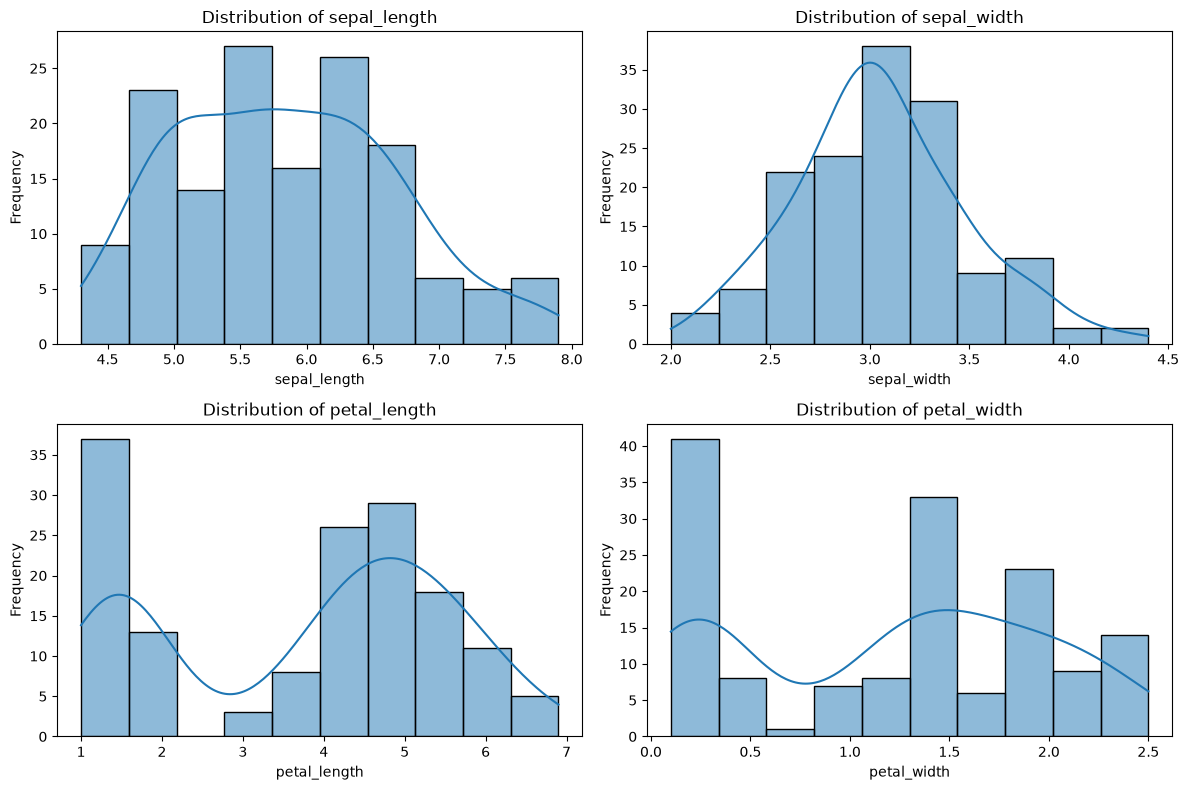

In [16]:
#Histograms Distribution
numeric_columns = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    
    sns.histplot(
        data=df,
        x=column,
        bins=10,
        kde=True,
        ax=axes[i],
        edgecolor='black'
    )

    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

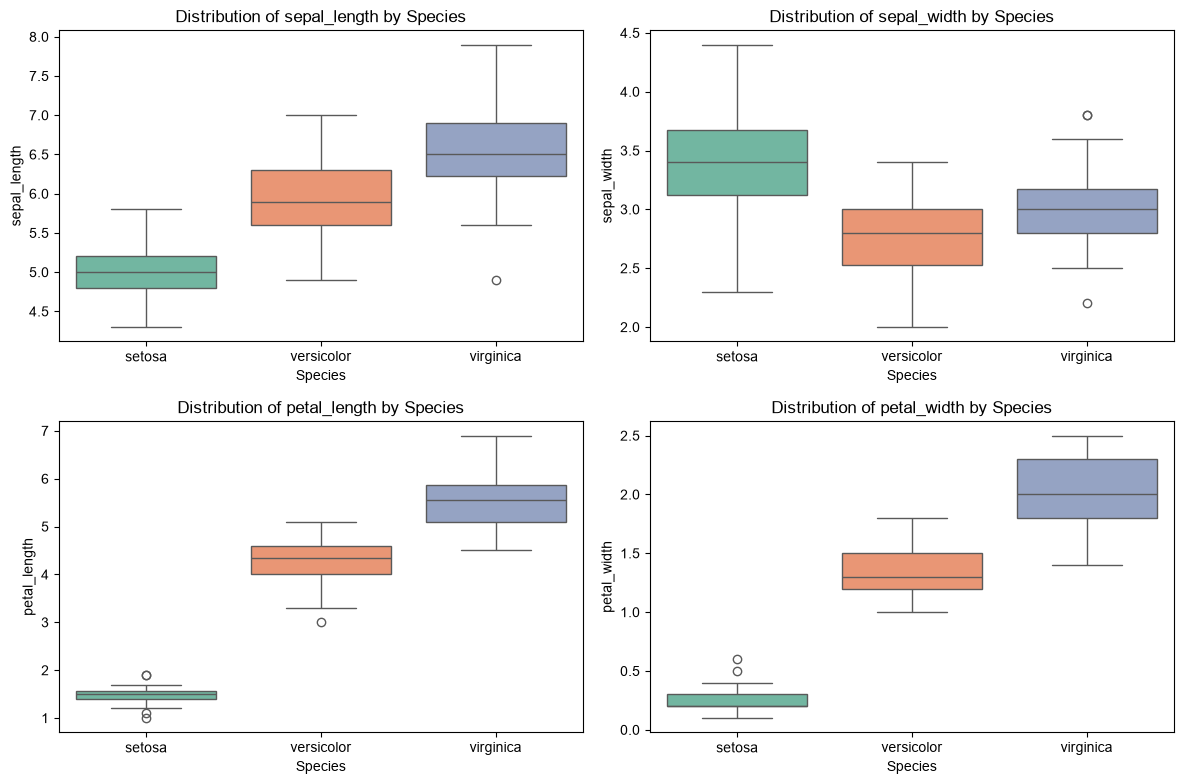

In [17]:
#Boxplots Distribution 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()
sns.set_theme(style= 'ticks')
for i, column in enumerate(numeric_columns):

    sns.boxplot(
        data=df,
        x='species',
        y=column,
        hue='species',
        ax=axes[i],
        palette="Set2"
    )
    
    axes[i].set_title(f'Distribution of {column} by Species')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(column)

plt.tight_layout()
plt.show()

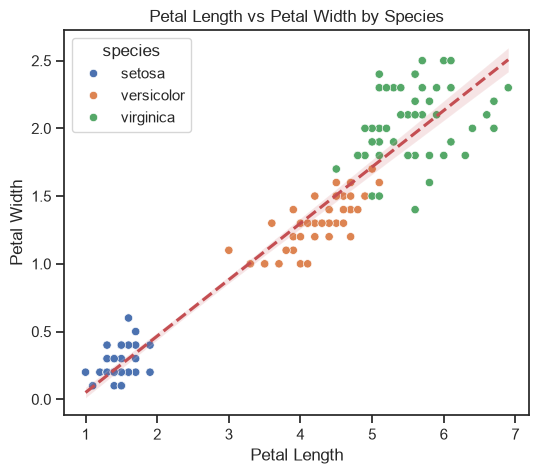

In [18]:
#Petal_length Vs Petal_width Scatterplot
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species'
)
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color= "r",
    line_kws={"linestyle" : "--"}
)
plt.title('Petal Length vs Petal Width by Species')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')

plt.show()

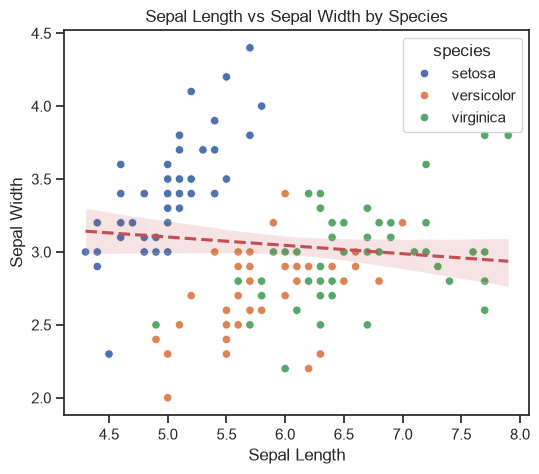

In [19]:
#Sepal_length Vs Sepal_width Scatterplot
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species'
)
sns.regplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    scatter=False,
    color= "r",
    line_kws={"linestyle" : "--"}
)
plt.title('Sepal Length vs Sepal Width by Species')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

plt.show()

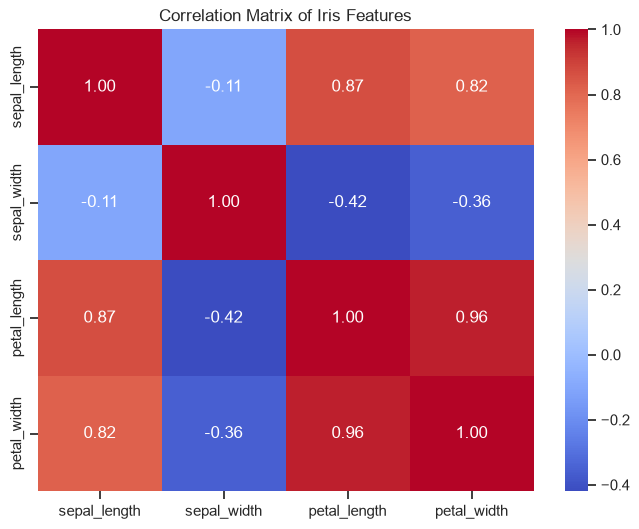

In [20]:
#Correlation Matrix of Numeric Features
df_correlation = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    data=df_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Iris Features')
plt.show()

Conclusion

The exploratory analysis shows that petal measurements provide clearer separation between Iris species than sepal measurements. Setosa is particularly distinct because of its shorter and narrower petals, while Versicolor and Virginica show more overlap. Petal length and petal width also demonstrate a strong positive relationship. These patterns suggest that petal characteristics may be particularly useful for distinguishing Iris species.